In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import  PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
df = pd.read_csv('retail_sales.csv')
df.head()

,date,store_id,item_id,sales,price,promo,weekday,month
0,2019-01-01,store_1,item_1,41,21.30,0,1.0,1.0
1,2019-01-02,store_1,item_1,53,21.30,0,2.0,1.0
2,2019-01-03,store_1,item_1,39,21.30,0,3.0,1.0
3,2019-01-04,store_1,item_1,35,21.30,0,4.0,1.0
4,2019-01-05,store_1,item_1,51,17.04,1,5.0,1.0


In [ ]:
df.shape

(75240, 8)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75240 entries, 0 to 75239
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   date      75240 non-null  object 
 1   store_id  75240 non-null  object 
 2   item_id   75240 non-null  object 
 3   sales     75240 non-null  int64  
 4   price     75240 non-null  float64
 5   promo     75240 non-null  int64  
 6   weekday   75239 non-null  float64
 7   month     75239 non-null  float64
dtypes: float64(3), int64(2), object(3)
memory usage: 4.6+ MB


In [ ]:
df.nunique()

,0
date,1826
store_id,1
item_id,42
sales,111
price,84
promo,2
weekday,7
month,12


In [ ]:
df.isnull().sum()

,0
date,0
store_id,0
item_id,0
sales,0
price,0
promo,0
weekday,1
month,1


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.isnull().sum()

,0
date,0
store_id,0
item_id,0
sales,0
price,0
promo,0
weekday,0
month,0


In [ ]:
for col in df.columns:
    unique_count = df[col].nunique()
    print(f"Number of unique values in column '{col}': {unique_count}")
    unique_values = df[col].unique()
    print(f"Unique values in column '{col}': {unique_values}")

Number of unique values in column 'date': 1826
Unique values in column 'date': ['2019-01-01' '2019-01-02' '2019-01-03' ... '2023-12-29' '2023-12-30'
 '2023-12-31']
Number of unique values in column 'store_id': 1
Unique values in column 'store_id': ['store_1']
Number of unique values in column 'item_id': 42
Unique values in column 'item_id': ['item_1' 'item_2' 'item_3' 'item_4' 'item_5' 'item_6' 'item_7' 'item_8'
 'item_9' 'item_10' 'item_11' 'item_12' 'item_13' 'item_14' 'item_15'
 'item_16' 'item_17' 'item_18' 'item_19' 'item_20' 'item_21' 'item_22'
 'item_23' 'item_24' 'item_25' 'item_26' 'item_27' 'item_28' 'item_29'
 'item_30' 'item_31' 'item_32' 'item_33' 'item_34' 'item_35' 'item_36'
 'item_37' 'item_38' 'item_39' 'item_40' 'item_41' 'item_42']
Number of unique values in column 'sales': 111
Unique values in column 'sales': [ 41  53  39  35  51  38  45  48  50  44  30  40  46  47  33  34  57  64
  54  58  37  42  82  56  36  55  49  63  60  85  59  83  52  61  80  79
  72  78  86 

In [ ]:
# EDA Comparisons

# 1. Sales by Store
# 2. Top-Selling Items Analysis
# 3. Item-Store Demand Comparison
# 4. Sales by Weekday (Weekly Seasonality)
# 5. Sales by Month (Monthly Seasonality)
# 6. Price vs Sales Relationship
# 7. Promotion Impact on Sales
# 8. Sales Distribution Analysis
# 9. Sales Trend Over Time

In [ ]:
#lets do eda graphs level to analyze the sales trend

In [ ]:
df.columns

Index(['date', 'store_id', 'item_id', 'sales', 'price', 'promo', 'weekday',
       'month'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 75239 entries, 0 to 75238
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   date      75239 non-null  object 
 1   store_id  75239 non-null  object 
 2   item_id   75239 non-null  object 
 3   sales     75239 non-null  int64  
 4   price     75239 non-null  float64
 5   promo     75239 non-null  int64  
 6   weekday   75239 non-null  float64
 7   month     75239 non-null  float64
dtypes: float64(3), int64(2), object(3)
memory usage: 5.2+ MB


In [ ]:
#lets start with comparing sales with store id
#total sales of each store than print the each store name and sales over complete region
#then plot a graph
store_sales = df.groupby('store_id')['sales'].sum()
print(store_sales)



store_id
store_1    2141968
Name: sales, dtype: int64


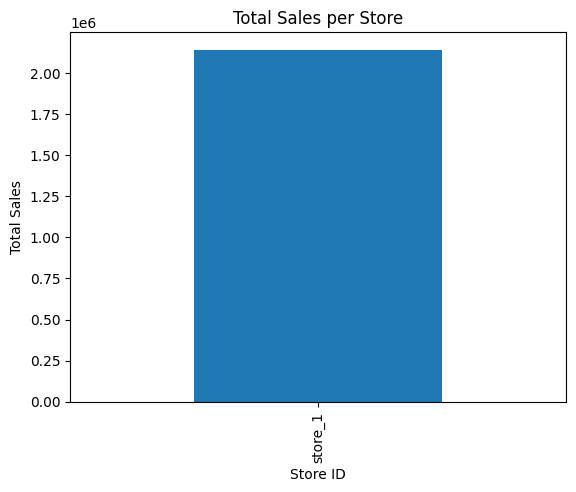

In [ ]:
import matplotlib.pyplot as plt

store_sales.plot(kind='bar')
plt.title('Total Sales per Store')
plt.xlabel('Store ID')
plt.ylabel('Total Sales')
plt.show()

In [ ]:
#Store 2 is dominating


In [ ]:
#lets calculate average sales
avg_sales = df.groupby('store_id')['sales'].mean()
print(avg_sales)


store_id
store_1    28.468853
Name: sales, dtype: float64


In [ ]:
#lets compare total sales with the items total 50 items
# like in total sale which item contribute most
item_sales = df.groupby('item_id')['sales'].sum()
print(item_sales)

item_id
item_1     81770
item_10    41315
item_11    44862
item_12    37762
item_13    73032
item_14    43007
item_15    38529
item_16    55170
item_17    29590
item_18    70474
item_19    25611
item_2     69280
item_20    82616
item_21    69114
item_22    33213
item_23    20977
item_24    72021
item_25    65091
item_26    66235
item_27    69076
item_28    25674
item_29    43289
item_3     79523
item_30    27765
item_31    75188
item_32    60198
item_33    41922
item_34    25048
item_35    40618
item_36    41530
item_37    66354
item_38    61237
item_39    76308
item_4     76878
item_40    50573
item_41    28451
item_42    12012
item_5     58323
item_6     79395
item_7     26265
item_8     33189
item_9     23483
Name: sales, dtype: int64


Text(0.5, 1.0, 'Total Sales per Item')

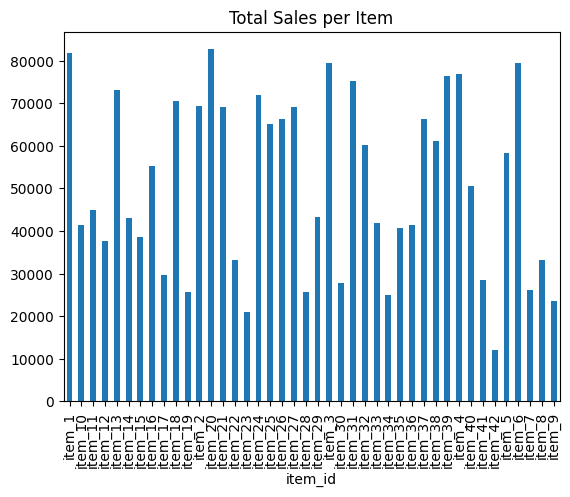

In [ ]:
import matplotlib.pyplot as plt
item_sales.plot(kind='bar')
plt.title('Total Sales per Item')

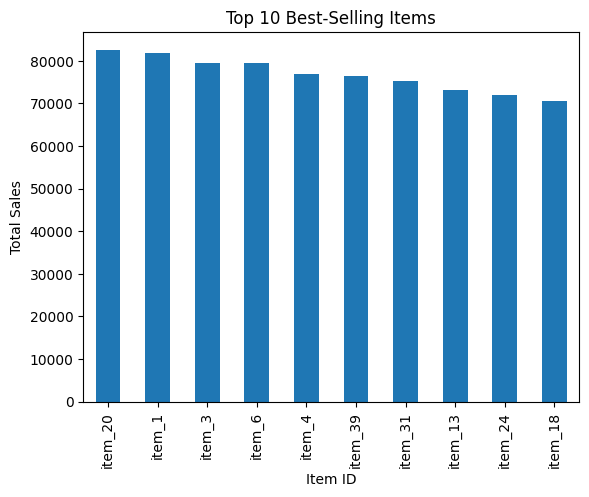

In [ ]:
#above graph is messy lets do for top 10 features
top_items = item_sales.sort_values(ascending=False).head(10)

top_items.plot(kind='bar')
plt.title('Top 10 Best-Selling Items')
plt.xlabel('Item ID')
plt.ylabel('Total Sales')
plt.show()

In [ ]:
# 3. Item-Store Demand Comparison
# lets analyze which store has which item in demand
item_store_sales = df.groupby(['store_id', 'item_id'])['sales'].sum()
print(item_store_sales)


store_id  item_id
store_1   item_1     81770
          item_10    41315
          item_11    44862
          item_12    37762
          item_13    73032
          item_14    43007
          item_15    38529
          item_16    55170
          item_17    29590
          item_18    70474
          item_19    25611
          item_2     69280
          item_20    82616
          item_21    69114
          item_22    33213
          item_23    20977
          item_24    72021
          item_25    65091
          item_26    66235
          item_27    69076
          item_28    25674
          item_29    43289
          item_3     79523
          item_30    27765
          item_31    75188
          item_32    60198
          item_33    41922
          item_34    25048
          item_35    40618
          item_36    41530
          item_37    66354
          item_38    61237
          item_39    76308
          item_4     76878
          item_40    50573
          item_41    28451
          

In [ ]:
top_items_per_store = item_store_sales.groupby('store_id').nlargest(5)

print(top_items_per_store)

store_id  store_id  item_id
store_1   store_1   item_20    82616
                    item_1     81770
                    item_3     79523
                    item_6     79395
                    item_4     76878
Name: sales, dtype: int64


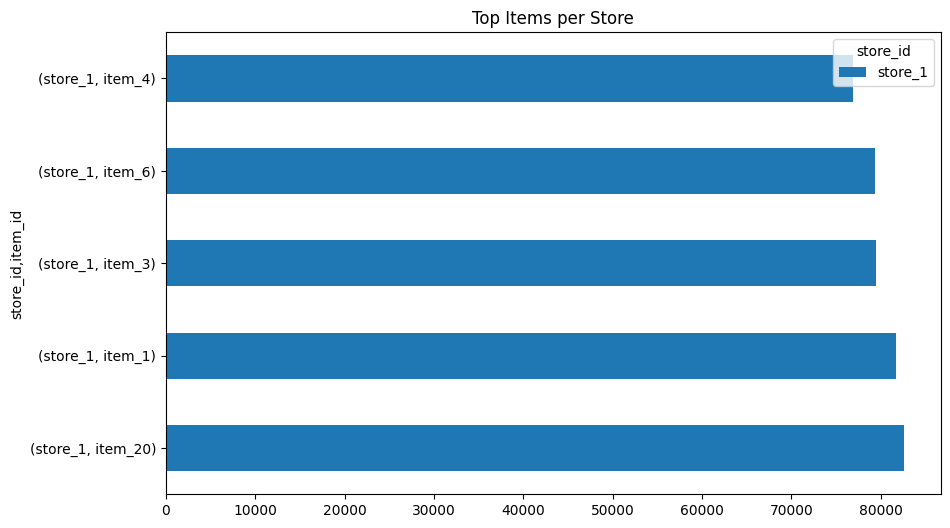

In [ ]:
top_items_per_store.unstack(level=0).plot(kind='barh', figsize=(10,6))
plt.title('Top Items per Store')
plt.show()

In [ ]:
# store 1 and 2 has top items same and 3 has just one different item
#store 2 is dominating


In [ ]:
sales_per_weekdays = df.groupby('weekday')['sales'].mean()
print(sales_per_weekdays)

weekday
0.0    28.369271
1.0    32.983171
2.0    34.023524
3.0    30.916961
4.0    26.000279
5.0    22.929329
6.0    24.058118
Name: sales, dtype: float64


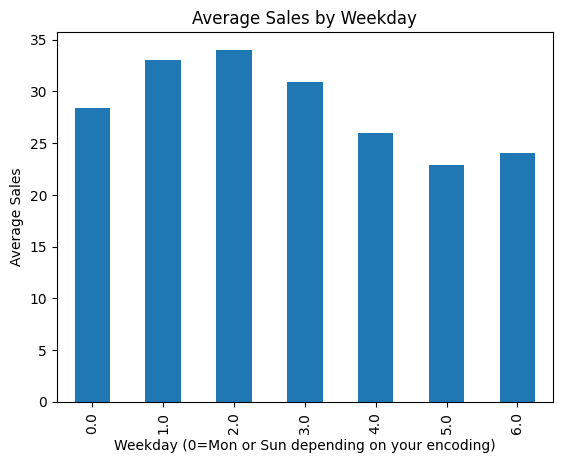

In [ ]:
import matplotlib.pyplot as plt

sales_per_weekdays.plot(kind='bar')
plt.title('Average Sales by Weekday')
plt.xlabel('Weekday (0=Mon or Sun depending on your encoding)')
plt.ylabel('Average Sales')
plt.show()

In [ ]:
#no difference on week days

In [ ]:
store_sales_per_weekdays = df.groupby(['store_id', 'weekday'])['sales'].mean()
print(store_sales_per_weekdays)

store_id  weekday
store_1   0.0        28.369271
          1.0        32.983171
          2.0        34.023524
          3.0        30.916961
          4.0        26.000279
          5.0        22.929329
          6.0        24.058118
Name: sales, dtype: float64


In [ ]:
pivot_table = df.pivot_table(
    values='sales',
    index='weekday',
    columns='store_id',
    aggfunc='mean'
)

print(pivot_table)

store_id    store_1
weekday            
0.0       28.369271
1.0       32.983171
2.0       34.023524
3.0       30.916961
4.0       26.000279
5.0       22.929329
6.0       24.058118


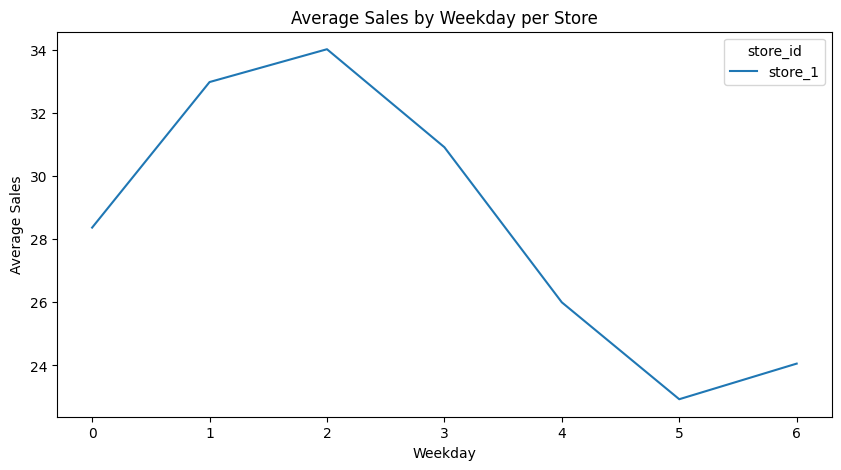

In [ ]:
pivot_table.plot(figsize=(10,5))
plt.title('Average Sales by Weekday per Store')
plt.xlabel('Weekday')
plt.ylabel('Average Sales')
plt.show()

In [ ]:
#Sales by Month overall (Monthly Seasonality)
sales_per_month = df.groupby('month')['sales'].mean()
print(sales_per_month)

month
1.0     30.140757
2.0     33.866414
3.0     36.180238
4.0     36.376375
5.0     34.371751
6.0     30.816828
7.0     26.325243
8.0     22.733010
9.0     20.676052
10.0    20.531788
11.0    23.014401
12.0    26.982462
Name: sales, dtype: float64


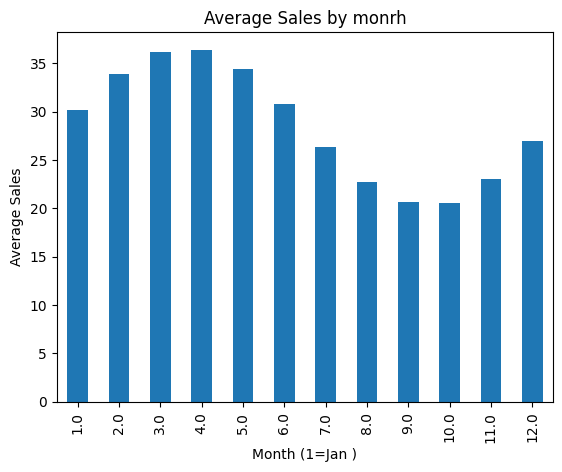

In [ ]:
import matplotlib.pyplot as plt

sales_per_month.plot(kind='bar')
plt.title('Average Sales by monrh')
plt.xlabel('Month (1=Jan )')
plt.ylabel('Average Sales')
plt.show()

In [ ]:
#sales by month by store
store_sales_per_month = df.groupby(['store_id', 'month'])['sales'].mean()
print(store_sales_per_month)

store_id  month
store_1   1.0      30.140757
          2.0      33.866414
          3.0      36.180238
          4.0      36.376375
          5.0      34.371751
          6.0      30.816828
          7.0      26.325243
          8.0      22.733010
          9.0      20.676052
          10.0     20.531788
          11.0     23.014401
          12.0     26.982462
Name: sales, dtype: float64


In [ ]:
pivot_table = df.pivot_table(
    values='sales',
    index='month',
    columns='store_id',
    aggfunc='mean'
)

print(pivot_table)

store_id    store_1
month              
1.0       30.140757
2.0       33.866414
3.0       36.180238
4.0       36.376375
5.0       34.371751
6.0       30.816828
7.0       26.325243
8.0       22.733010
9.0       20.676052
10.0      20.531788
11.0      23.014401
12.0      26.982462


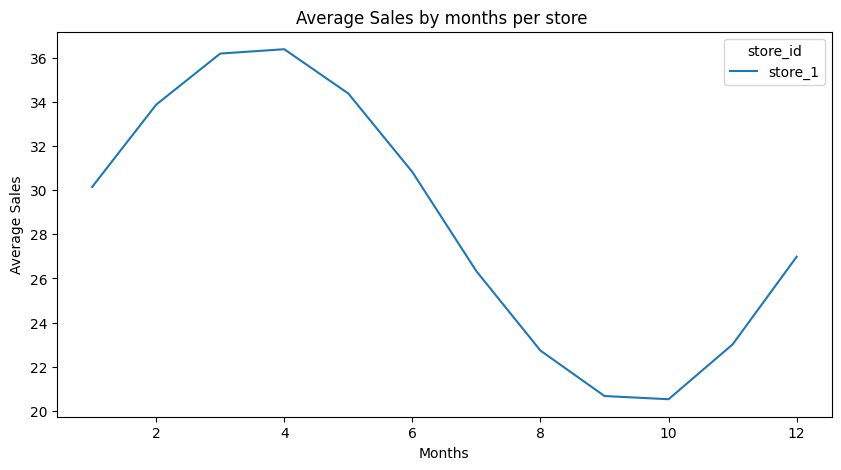

In [ ]:
pivot_table.plot(figsize=(10,5))
plt.title('Average Sales by months per store ')
plt.xlabel('Months')
plt.ylabel('Average Sales')
plt.show()

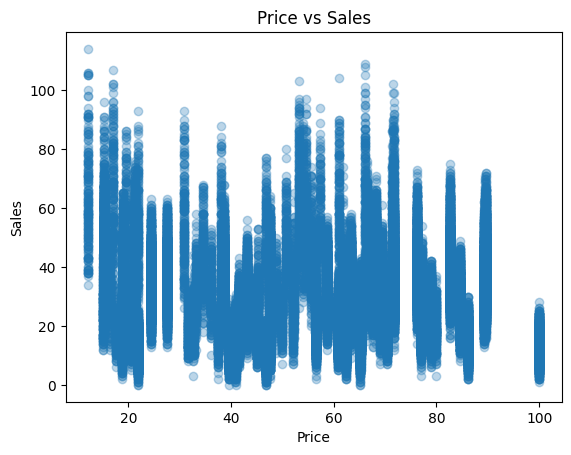

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(df['price'], df['sales'], alpha=0.3)
plt.title('Price vs Sales')
plt.xlabel('Price')
plt.ylabel('Sales')
plt.show()

In [ ]:
df['price_bin'] = pd.cut(df['price'], bins=10)

price_sales = df.groupby('price_bin')['sales'].mean()
print(price_sales)

price_bin
(12.112, 20.979]    32.373388
(20.979, 29.758]    31.923565
(29.758, 38.537]    31.954343
(38.537, 47.316]    20.494383
(47.316, 56.095]    31.456963
(56.095, 64.874]    25.567156
(64.874, 73.653]    31.655660
(73.653, 82.432]    27.930883
(82.432, 91.211]    32.678937
(91.211, 99.99]     13.279656
Name: sales, dtype: float64


/tmp/ipython-input-3847604171.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_sales = df.groupby('price_bin')['sales'].mean()


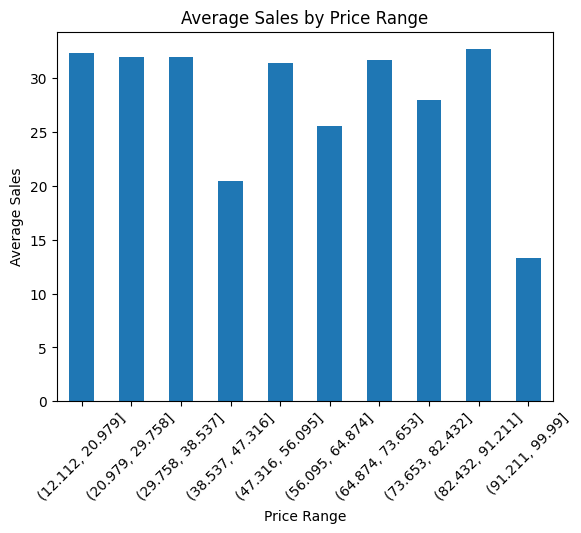

In [ ]:
price_sales.plot(kind='bar')
plt.title('Average Sales by Price Range')
plt.xlabel('Price Range')
plt.ylabel('Average Sales')
plt.xticks(rotation=45)
plt.show()

In [ ]:
df[['price', 'sales']].corr()

,price,sales
price,1.000000,-0.000142
sales,-0.000142,1.000000


In [ ]:
#means no correlation

In [ ]:
#now lets analyze this by means of stores
import pandas as pd
import matplotlib.pyplot as plt

# Create price bins (10 ranges)
df['price_bin'] = pd.cut(df['price'], bins=10)

# Group by store and price_bin
price_store_sales = df.groupby(['store_id', 'price_bin'])['sales'].mean().unstack(level=0)

print(price_store_sales)

store_id            store_1
price_bin                  
(12.112, 20.979]  32.373388
(20.979, 29.758]  31.923565
(29.758, 38.537]  31.954343
(38.537, 47.316]  20.494383
(47.316, 56.095]  31.456963
(56.095, 64.874]  25.567156
(64.874, 73.653]  31.655660
(73.653, 82.432]  27.930883
(82.432, 91.211]  32.678937
(91.211, 99.99]   13.279656


/tmp/ipython-input-2483625972.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_store_sales = df.groupby(['store_id', 'price_bin'])['sales'].mean().unstack(level=0)


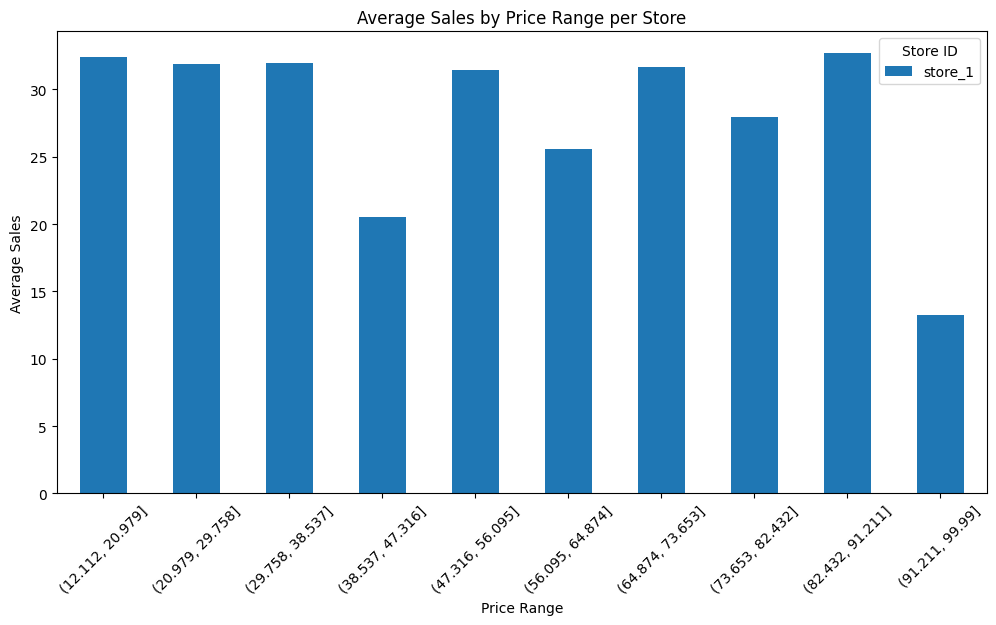

In [ ]:
price_store_sales.plot(kind='bar', figsize=(12,6))
plt.title('Average Sales by Price Range per Store')
plt.xlabel('Price Range')
plt.ylabel('Average Sales')
plt.xticks(rotation=45)
plt.legend(title='Store ID')
plt.show()

In [ ]:
promo_sales = df.groupby('promo')['sales'].mean()
print(promo_sales)

promo
0    27.099500
1    41.003509
Name: sales, dtype: float64


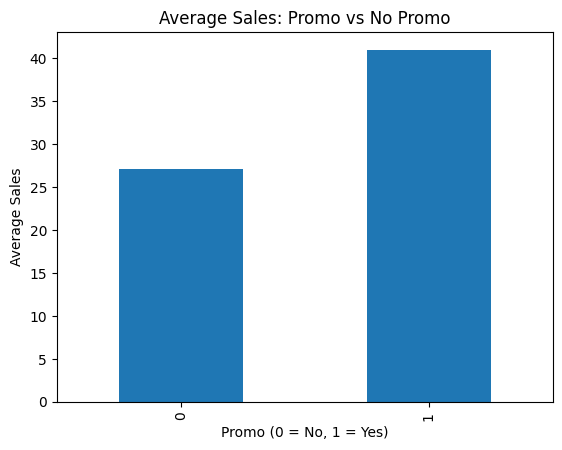

In [ ]:
import matplotlib.pyplot as plt

promo_sales.plot(kind='bar')
plt.title('Average Sales: Promo vs No Promo')
plt.xlabel('Promo (0 = No, 1 = Yes)')
plt.ylabel('Average Sales')
plt.show()

In [ ]:
store_promo_sales = df.groupby(['store_id', 'promo'])['sales'].mean().unstack(level=1)
print(store_promo_sales)

promo           0          1
store_id                    
store_1   27.0995  41.003509


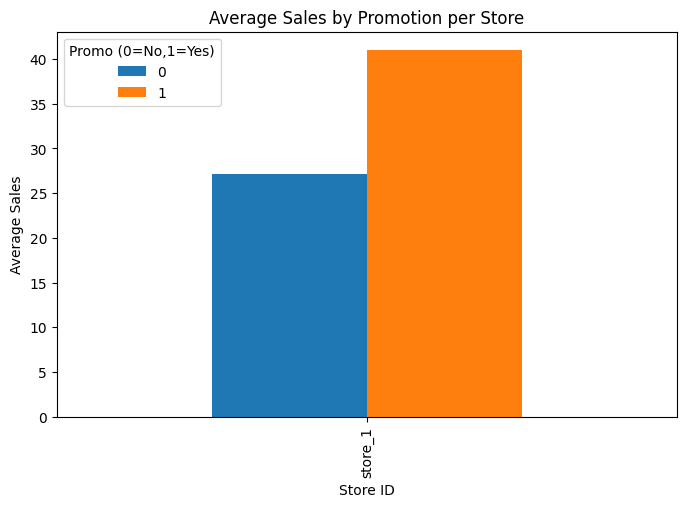

In [ ]:
store_promo_sales.plot(kind='bar', figsize=(8,5))
plt.title('Average Sales by Promotion per Store')
plt.xlabel('Store ID')
plt.ylabel('Average Sales')
plt.legend(title='Promo (0=No,1=Yes)')
plt.show()

In [ ]:
import pandas as pd

# Step 1: Group by item and promo
item_promo_sales = df.groupby(['item_id', 'promo'])['sales'].mean().unstack(level=1)

# Step 2: Rename columns for clarity
# Check the columns first
print("Columns after unstack:", item_promo_sales.columns)

# Ensure columns exist
if 0 in item_promo_sales.columns and 1 in item_promo_sales.columns:
    item_promo_sales.columns = ['No_Promo', 'Promo']
else:
    # If promo values are not 0/1 exactly, adapt this
    item_promo_sales.columns = [f'Promo_{c}' for c in item_promo_sales.columns]

# Step 3: Calculate promo increase
item_promo_sales['Promo_Increase'] = item_promo_sales['Promo'] - item_promo_sales['No_Promo']

# Step 4: View the result
print(item_promo_sales.head(10))

Columns after unstack: Index([0, 1], dtype='int64', name='promo')
          No_Promo      Promo  Promo_Increase
item_id                                      
item_1   42.578563  64.434783       21.856220
item_10  21.448234  33.135870       11.687636
item_11  23.378852  36.081871       12.703019
item_12  19.690534  29.842697       10.152163
item_13  38.099755  56.130208       18.030453
item_14  22.573229  33.750000       11.176771
item_15  20.075426  30.357143       10.281717
item_16  28.751065  43.344262       14.593197
item_17  15.543269  23.000000        7.456731
item_18  36.929087  55.703704       18.774617


In [ ]:
top_promo_items = item_promo_sales['Promo_Increase'].sort_values(ascending=False).head(10)
print("Top 10 Items Most Affected by Promotion:")
print(top_promo_items)

Top 10 Items Most Affected by Promotion:
item_id
item_3     23.700170
item_6     22.273206
item_1     21.856220
item_20    20.914663
item_39    20.347895
item_4     20.317639
item_31    20.126958
item_27    19.452964
item_24    19.247129
item_37    19.102530
Name: Promo_Increase, dtype: float64


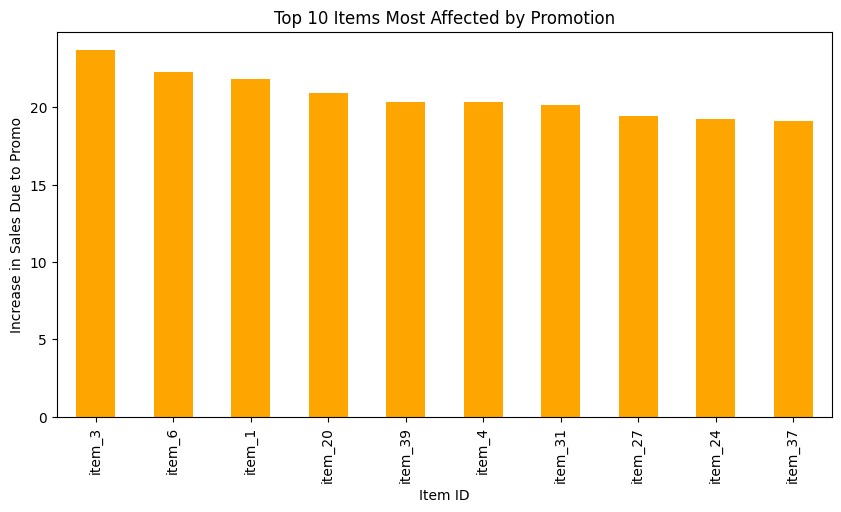

In [ ]:
import matplotlib.pyplot as plt

# Bar plot for top 10 items
top_promo_items.plot(kind='bar', figsize=(10,5), color='orange')
plt.title('Top 10 Items Most Affected by Promotion')
plt.xlabel('Item ID')
plt.ylabel('Increase in Sales Due to Promo')
plt.show()

In [ ]:
#promotion increase sales

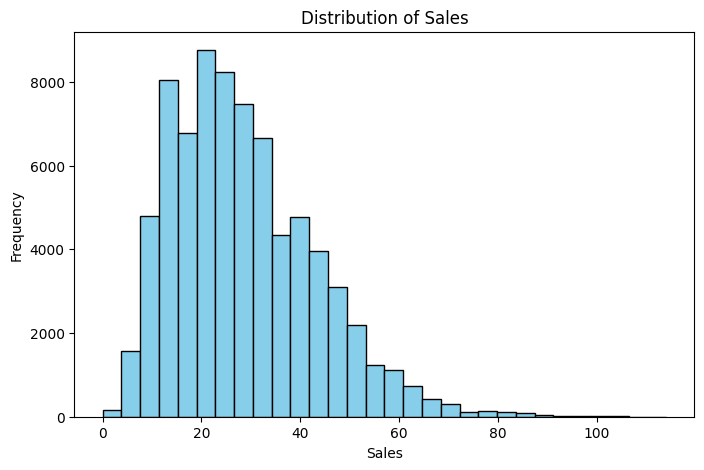

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['sales'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

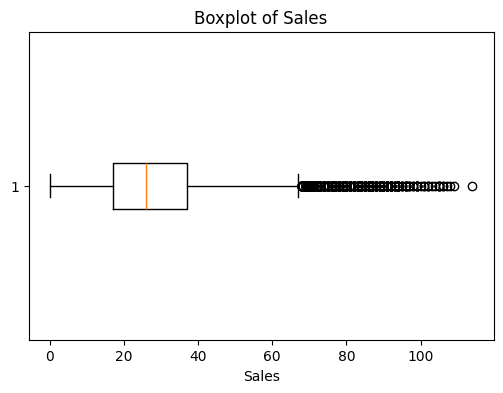

In [ ]:
plt.figure(figsize=(6,4))
plt.boxplot(df['sales'], vert=False)
plt.title('Boxplot of Sales')
plt.xlabel('Sales')
plt.show()

/tmp/ipython-input-952443576.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(store_sales_dist, labels=df['store_id'].unique())


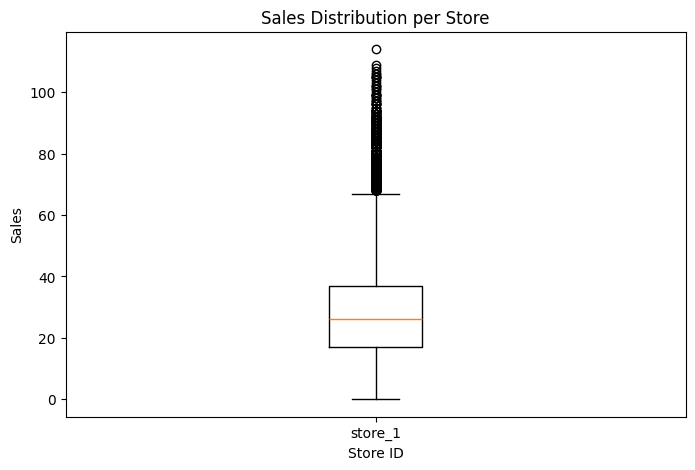

In [ ]:
store_sales_dist = [df[df['store_id']==s]['sales'] for s in df['store_id'].unique()]

plt.figure(figsize=(8,5))
plt.boxplot(store_sales_dist, labels=df['store_id'].unique())
plt.title('Sales Distribution per Store')
plt.xlabel('Store ID')
plt.ylabel('Sales')
plt.show()

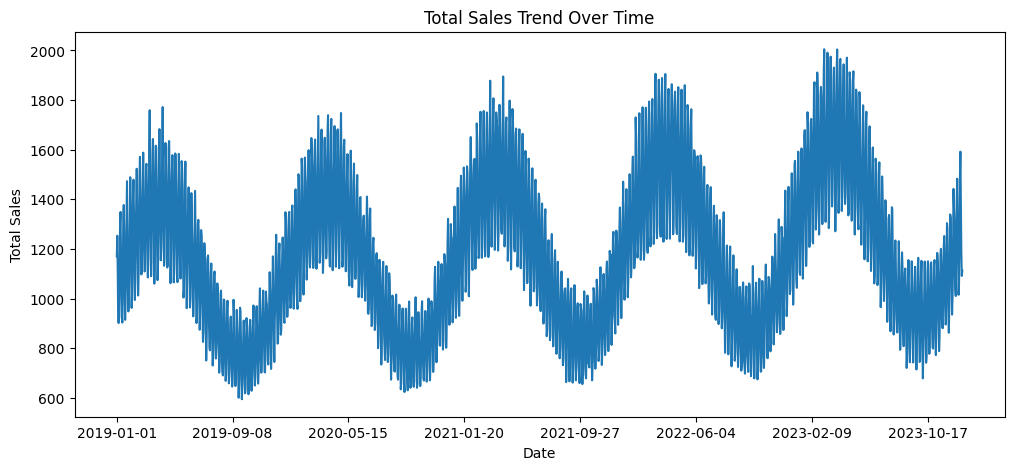

In [ ]:
import matplotlib.pyplot as plt

# Aggregate total sales per day
daily_sales = df.groupby('date')['sales'].sum()

plt.figure(figsize=(12,5))
daily_sales.plot()
plt.title('Total Sales Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.show()

<Figure size 1200x500 with 0 Axes>

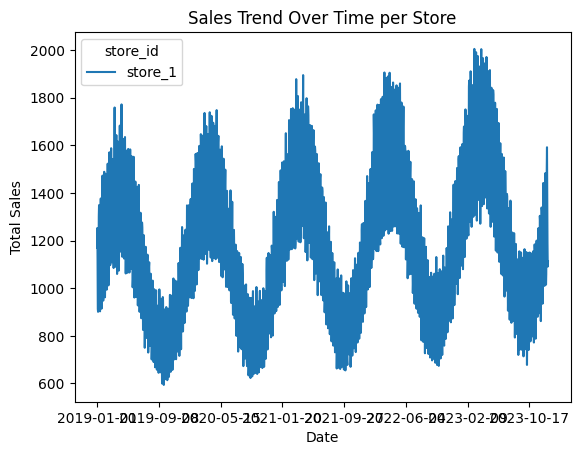

In [ ]:
store_daily_sales = df.groupby(['date', 'store_id'])['sales'].sum().unstack()

plt.figure(figsize=(12,5))
store_daily_sales.plot()
plt.title('Sales Trend Over Time per Store')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.show()

In [ ]:
# List of all EDA variables
eda_variables = [
    'store_sales',              # Total sales per store
    'item_sales',               # Total sales per item
    'item_store_sales',         # Total sales per item per store
    'top_items_per_store',      # Top N items per store
    'sales_per_weekdays',       # Average sales per weekday
    'pivot_table',              # Average sales per weekday per store
    'daily_sales',              # Total sales per day
    'store_daily_sales',        # Total sales per day per store
    'sales_per_price',          # Average sales per price (all stores)
    "df['price_bin']",          # Price bins
    'price_sales',              # Average sales per price range (all stores)
    'price_store_sales',        # Average sales per price range per store
    'promo_sales',              # Average sales promo vs no promo (overall)
    'store_promo_sales',        # Average sales promo vs no promo per store
    'item_promo_sales',         # Average sales promo vs no promo per item

    'store_sales_dist',         # List of sales per store for boxplot
    'top_items',                # Top 10 items for distribution analysis
]

# Print all variables and check if they exist
print("=== List of EDA Variables and Their Status ===")
for var in eda_variables:
    try:
        # Evaluate the variable dynamically
        val = eval(var)
        print(f"{var}: EXISTS")
    except NameError:
        print(f"{var}: NOT DEFINED")

=== List of EDA Variables and Their Status ===
store_sales: EXISTS
item_sales: EXISTS
item_store_sales: EXISTS
top_items_per_store: EXISTS
sales_per_weekdays: EXISTS
pivot_table: EXISTS
daily_sales: EXISTS
store_daily_sales: EXISTS
sales_per_price: EXISTS
df['price_bin']: EXISTS
price_sales: EXISTS
price_store_sales: EXISTS
promo_sales: EXISTS
store_promo_sales: EXISTS
item_promo_sales: EXISTS
store_sales_dist: EXISTS
top_items: EXISTS


In [ ]:
import pandas as pd
import numpy as np

# -------------------------------
# 1️⃣ Price binning
# -------------------------------
df['price_bin'] = pd.cut(df['price'], bins=10)

# -------------------------------
# 2️⃣ Aggregate Features
# -------------------------------

# Store-level average sales
store_sales = df.groupby('store_id')['sales'].mean()
df['avg_sales_per_store'] = df['store_id'].map(store_sales)

# Item-level average sales
item_sales = df.groupby('item_id')['sales'].mean()
df['avg_sales_per_item'] = df['item_id'].map(item_sales)

# Item + Store-level sales
item_store_sales = df.groupby(['store_id','item_id'])['sales'].mean()
df = df.merge(
    item_store_sales.reset_index().rename(columns={'sales':'avg_sales_item_store'}),
    on=['store_id','item_id'],
    how='left'
)

# Price bin average sales (overall)
price_sales = df.groupby('price_bin')['sales'].mean()
df['avg_sales_per_price_bin'] = df['price_bin'].map(price_sales)

# Price bin + Store average sales
price_store_sales = df.groupby(['price_bin','store_id'])['sales'].mean().reset_index()
df = df.merge(
    price_store_sales.rename(columns={'sales':'avg_sales_price_store'}),
    on=['price_bin','store_id'],
    how='left'
)

# -------------------------------
# 3️⃣ Promotion Features
# -------------------------------

# Promo effect per item
item_promo_sales = df.groupby(['item_id','promo'])['sales'].mean().unstack()
# Ensure columns exist
item_promo_sales.columns = ['No_Promo','Promo']
item_promo_sales['Promo_Increase'] = item_promo_sales['Promo'] - item_promo_sales['No_Promo']

df['promo_effect_item'] = df['item_id'].map(item_promo_sales['Promo_Increase'])

# Promo effect per store
store_promo_sales = df.groupby(['store_id','promo'])['sales'].mean().unstack()
store_promo_sales['Promo_Increase'] = store_promo_sales[1] - store_promo_sales[0]
df['promo_effect_store'] = df['store_id'].map(store_promo_sales['Promo_Increase'])

# -------------------------------
# 4️⃣ Weekday / Pivot Features
# -------------------------------

# Avg sales per weekday
sales_per_weekdays = df.groupby('weekday')['sales'].mean()
df['avg_sales_per_weekday'] = df['weekday'].map(sales_per_weekdays)

# Store + Weekday pivot
pivot_table = df.pivot_table(values='sales', index='weekday', columns='store_id', aggfunc='mean').reset_index()
df = df.merge(
    pivot_table.melt(id_vars='weekday', var_name='store_id', value_name='avg_sales_store_weekday'),
    on=['weekday','store_id'],
    how='left'
)

# -------------------------------
# 5️⃣ Month / Seasonal Features
# -------------------------------

# Avg sales per month
monthly_sales = df.groupby('month')['sales'].mean()
df['avg_sales_per_month'] = df['month'].map(monthly_sales)

# Weekend flag
df['is_weekend'] = df['weekday'].isin([0,6]).astype(int)

# -------------------------------
# 6️⃣ Lag / Rolling Features (optional)
# -------------------------------

df = df.sort_values(['item_id','date'])

# Lag 1-day sales per item
df['lag_1_sales_item'] = df.groupby('item_id')['sales'].shift(1)

# Rolling 7-day mean sales per item
df['rolling_7_sales_item'] = df.groupby('item_id')['sales'].rolling(7).mean().reset_index(0,drop=True)

# -------------------------------
# 7️⃣ Final check
# -------------------------------
print("ML-ready DataFrame shape:", df.shape)
print(df.head())

/tmp/ipython-input-3498904493.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_sales = df.groupby('price_bin')['sales'].mean()
/tmp/ipython-input-3498904493.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_store_sales = df.groupby(['price_bin','store_id'])['sales'].mean().reset_index()


ML-ready DataFrame shape: (75239, 22)
         date store_id item_id  sales  price  promo  weekday  month  \
0  2019-01-01  store_1  item_1     41  21.30      0      1.0    1.0   
1  2019-01-02  store_1  item_1     53  21.30      0      2.0    1.0   
2  2019-01-03  store_1  item_1     39  21.30      0      3.0    1.0   
3  2019-01-04  store_1  item_1     35  21.30      0      4.0    1.0   
4  2019-01-05  store_1  item_1     51  17.04      1      5.0    1.0   

          price_bin  avg_sales_per_store  ...  avg_sales_per_price_bin  \
0  (20.979, 29.758]            28.468853  ...                31.923565   
1  (20.979, 29.758]            28.468853  ...                31.923565   
2  (20.979, 29.758]            28.468853  ...                31.923565   
3  (20.979, 29.758]            28.468853  ...                31.923565   
4  (12.112, 20.979]            28.468853  ...                32.373388   

   avg_sales_price_store promo_effect_item  promo_effect_store  \
0              31.923565

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 75239 entries, 0 to 16433
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   date                     75239 non-null  object  
 1   store_id                 75239 non-null  object  
 2   item_id                  75239 non-null  object  
 3   sales                    75239 non-null  int64   
 4   price                    75239 non-null  float64 
 5   promo                    75239 non-null  int64   
 6   weekday                  75239 non-null  float64 
 7   month                    75239 non-null  float64 
 8   price_bin                75239 non-null  category
 9   avg_sales_per_store      75239 non-null  float64 
 10  avg_sales_per_item       75239 non-null  float64 
 11  avg_sales_item_store     75239 non-null  float64 
 12  avg_sales_per_price_bin  75239 non-null  category
 13  avg_sales_price_store    75239 non-null  float64 
 14  promo_effec

In [ ]:
df['date'].nunique()

1826

In [ ]:
df['store_id']

,store_id
0,store_1
1,store_1
2,store_1
3,store_1
4,store_1
...,...
16429,store_1
16430,store_1
16431,store_1
16432,store_1


In [ ]:
df['store_id'] = df['store_id'].replace({'store_1':1, 'store_2':2, 'store_3':3})

/tmp/ipython-input-712919887.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['store_id'] = df['store_id'].replace({'store_1':1, 'store_2':2, 'store_3':3})


In [ ]:
df['store_id']

,store_id
0,1
1,1
2,1
3,1
4,1
...,...
16429,1
16430,1
16431,1
16432,1


In [ ]:
df['item_id'].nunique()

42

In [ ]:
# Create mapping for items
item_mapping = {f'item_{i}': i for i in range(1, 51)}

# Apply mapping
df['item_id'] = df['item_id'].map(item_mapping)

In [ ]:
df['item_id']

,item_id
0,1
1,1
2,1
3,1
4,1
...,...
16429,9
16430,9
16431,9
16432,9


In [ ]:
df['avg_sales_per_store'].unique()

array([28.46885259])

In [ ]:
df['avg_sales_per_store_float'] = df['avg_sales_per_store'].astype(float)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 75239 entries, 0 to 16433
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   date                       75239 non-null  object  
 1   store_id                   75239 non-null  int64   
 2   item_id                    75239 non-null  int64   
 3   sales                      75239 non-null  int64   
 4   price                      75239 non-null  float64 
 5   promo                      75239 non-null  int64   
 6   weekday                    75239 non-null  float64 
 7   month                      75239 non-null  float64 
 8   price_bin                  75239 non-null  category
 9   avg_sales_per_store        75239 non-null  float64 
 10  avg_sales_per_item         75239 non-null  float64 
 11  avg_sales_item_store       75239 non-null  float64 
 12  avg_sales_per_price_bin    75239 non-null  category
 13  avg_sales_price_store      75239 non

In [ ]:
df = df.drop('avg_sales_per_price_bin', axis=1)

In [ ]:
df = df.drop('date', axis=1)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 75239 entries, 0 to 16433
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   store_id                   75239 non-null  int64  
 1   item_id                    75239 non-null  int64  
 2   sales                      75239 non-null  int64  
 3   price                      75239 non-null  float64
 4   promo                      75239 non-null  int64  
 5   weekday                    75239 non-null  float64
 6   month                      75239 non-null  float64
 7   avg_sales_per_store        75239 non-null  float64
 8   avg_sales_per_item         75239 non-null  float64
 9   avg_sales_item_store       75239 non-null  float64
 10  avg_sales_price_store      75239 non-null  float64
 11  promo_effect_item          75239 non-null  float64
 12  promo_effect_store         75239 non-null  float64
 13  avg_sales_per_weekday      75239 non-null  float64


In [ ]:
num_duplicates = df.duplicated().sum()
print("Number of duplicated rows:", num_duplicates)


Number of duplicated rows: 89


In [ ]:
df = df.drop_duplicates()  # drops rows duplicated across all columns



In [ ]:
num_duplicates = df.duplicated().sum()
print("Number of duplicated rows:", num_duplicates)


Number of duplicated rows: 0


In [ ]:
df.shape

(75150, 20)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 75150 entries, 0 to 16433
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   store_id                   75150 non-null  int64  
 1   item_id                    75150 non-null  int64  
 2   sales                      75150 non-null  int64  
 3   price                      75150 non-null  float64
 4   promo                      75150 non-null  int64  
 5   weekday                    75150 non-null  float64
 6   month                      75150 non-null  float64
 7   avg_sales_per_store        75150 non-null  float64
 8   avg_sales_per_item         75150 non-null  float64
 9   avg_sales_item_store       75150 non-null  float64
 10  avg_sales_price_store      75150 non-null  float64
 11  promo_effect_item          75150 non-null  float64
 12  promo_effect_store         75150 non-null  float64
 13  avg_sales_per_weekday      75150 non-null  float64


In [ ]:
import xgboost as xgb

In [ ]:
from sklearn.metrics import mean_squared_error

In [ ]:
import pickle

In [ ]:
store_avg = df.groupby('store_id')['avg_sales_per_store'].mean().to_dict()
item_avg = df.groupby('item_id')['avg_sales_per_item'].mean().to_dict()
item_store_avg = df.groupby(['store_id','item_id'])['avg_sales_item_store'].mean().to_dict()
month_avg = df.groupby('month')['avg_sales_per_month'].mean().to_dict()
promo_item = df.groupby('item_id')['promo_effect_item'].mean().to_dict()
promo_store = df.groupby('store_id')['promo_effect_store'].mean().to_dict()

In [ ]:
features = [
    'store_id',
    'item_id',
    'month',
    'avg_sales_per_store',
    'avg_sales_per_item',
    'avg_sales_item_store',
    'avg_sales_per_month',
    'promo_effect_item',
    'promo_effect_store'
]

In [ ]:
X = df[features]
y = df['sales']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train

,store_id,item_id,month,avg_sales_per_store,avg_sales_per_item,avg_sales_item_store,avg_sales_per_month,promo_effect_item,promo_effect_store
15709,1,9,1.0,28.468853,12.860350,12.860350,30.140757,6.622387,13.904009
63212,1,35,2.0,28.468853,22.244250,22.244250,33.866414,10.775501,13.904009
69594,1,39,7.0,28.468853,41.789704,41.789704,26.325243,20.347895,13.904009
9790,1,6,10.0,28.468853,43.480285,43.480285,20.531788,22.273206,13.904009
37193,1,21,11.0,28.468853,37.849945,37.849945,23.014401,18.156850,13.904009
...,...,...,...,...,...,...,...,...,...
50016,1,28,12.0,28.468853,14.060241,14.060241,26.982462,7.162555,13.904009
20879,1,12,3.0,28.468853,20.680175,20.680175,36.180238,10.152163,13.904009
65909,1,37,6.0,28.468853,36.338445,36.338445,30.816828,19.102530,13.904009
860,1,1,5.0,28.468853,44.780942,44.780942,34.371751,21.856220,13.904009


In [ ]:
y_train

,sales
15709,11
63212,28
69594,30
9790,30
37193,31
...,...
50016,12
20879,29
65909,26
860,56


In [ ]:
model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)


In [ ]:
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 7.526971258460045


In [ ]:
with open('store_item_model.pkl', 'wb') as f:
    pickle.dump(model, f)

In [ ]:
# Load model
with open('store_item_model.pkl', 'rb') as f:
    model = pickle.load(f)

def predict_sales_simple(store_id, item_id, month):
    X_input = pd.DataFrame([[
        store_id,
        item_id,
        month,
        store_avg.get(store_id, 0),
        item_avg.get(item_id, 0),
        item_store_avg.get((store_id,item_id), 0),
        month_avg.get(month, 0),
        promo_item.get(item_id, 0),
        promo_store.get(store_id, 0)
    ]], columns=features)

    prediction = model.predict(X_input)[0]
    return round(prediction, 2)

In [ ]:
import random

# Pick a random row from your dataframe
random_row = df.sample(1).iloc[0]

# Extract store, item, month, and sales
store_input = random_row['store_id']
item_input = random_row['item_id']
month_input = random_row['month']
actual_sales = random_row['sales']

# Display
print("Randomly selected historical data:")
print(f"Store ID: {store_input}")
print(f"Item ID: {item_input}")
print(f"Month: {month_input}")
print(f"Actual sales: {actual_sales}")

# Now you can feed the same inputs to your model
predicted = predict_sales_simple(store_input, item_input, month_input)
print(f"Predicted sales: {predicted}")

Randomly selected historical data:
Store ID: 1.0
Item ID: 4.0
Month: 8.0
Actual sales: 34.0
Predicted sales: 33.880001068115234


In [ ]:
predicted = predict_sales_simple(store_id=2, item_id=40, month=10)
print(f"Predicted sales: {predicted}")

Predicted sales: 19.979999542236328
